In [1]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv("../data/Used_Car_Price_Prediction.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 7400
Columns: 29


In [3]:
df.head()

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False


In [4]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['car_name', 'yr_mfr', 'fuel_type', 'kms_run', 'sale_price', 'city', 'times_viewed', 'body_type', 'transmission', 'variant', 'assured_buy', 'registered_city', 'registered_state', 'is_hot', 'rto', 'source', 'make', 'model', 'car_availability', 'total_owners', 'broker_quote', 'original_price', 'car_rating', 'ad_created_on', 'fitness_certificate', 'emi_starts_from', 'booking_down_pymnt', 'reserved', 'warranty_avail']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             7400 non-null   str    
 1   yr_mfr               7400 non-null   int64  
 2   fuel_type            7400 non-null   str    
 3   kms_run              7400 non-null   int64  
 4   sale_price           7400 non-null   int64  
 5   city                 7400 non-null   str    
 6   times_viewed         7400 non-null   int64  
 7   body_type            7297 non-null   str    
 8   transmission         6844 non-null   str    
 9   variant              7400 non-null   str    
 10  assured_buy          7400 non-null   bool   
 11  registered_city      7390 non-null   str    
 12  registered_state     7390 non-null   str    
 13  is_hot               7400 non-null   bool   
 14  rto                  7400 non-null   str    
 15  source               7274 non-null   str    
 16 

In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
car_name                  0
yr_mfr                    0
fuel_type                 0
kms_run                   0
sale_price                0
city                      0
times_viewed              0
body_type               103
transmission            556
variant                   0
assured_buy               0
registered_city          10
registered_state         10
is_hot                    0
rto                       0
source                  126
make                      0
model                     0
car_availability        620
total_owners              0
broker_quote              0
original_price         3280
car_rating                9
ad_created_on             1
fitness_certificate       8
emi_starts_from           0
booking_down_pymnt        0
reserved                  0
warranty_avail            0
dtype: int64


In [7]:
# Complete missing-value summary
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

print("\nMissing percentage:")
print((missing / len(df) * 100).round(2))

Columns with missing values:
original_price         3280
car_availability        620
transmission            556
source                  126
body_type               103
registered_state         10
registered_city          10
car_rating                9
fitness_certificate       8
ad_created_on             1
dtype: int64

Missing percentage:
original_price         44.32
car_availability        8.38
transmission            7.51
source                  1.70
body_type               1.39
registered_state        0.14
registered_city         0.14
car_rating              0.12
fitness_certificate     0.11
ad_created_on           0.01
dtype: float64


In [8]:
# Data types of all columns
print(df.dtypes)

car_name                   str
yr_mfr                   int64
fuel_type                  str
kms_run                  int64
sale_price               int64
city                       str
times_viewed             int64
body_type                  str
transmission               str
variant                    str
assured_buy               bool
registered_city            str
registered_state           str
is_hot                    bool
rto                        str
source                     str
make                       str
model                      str
car_availability           str
total_owners             int64
broker_quote             int64
original_price         float64
car_rating                 str
ad_created_on              str
fitness_certificate     object
emi_starts_from          int64
booking_down_pymnt       int64
reserved                  bool
warranty_avail            bool
dtype: object


In [9]:
# Statistical summary
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_name,7400,185,maruti swift,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
yr_mfr,7400.0,NaN,NaN,NaN,2013.885676,3.087613,1996.0,2012.0,2014.0,2016.0,2021.0
fuel_type,7400,5,petrol,4659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kms_run,7400.0,NaN,NaN,NaN,62624.52,43532.042371,60.0,31885.25,55765.0,84184.0,996609.0
sale_price,7400.0,NaN,NaN,NaN,454889.192027,282702.329741,0.0,281174.0,382449.0,540149.0,3866000.0
city,7400,13,mumbai,1336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
times_viewed,7400.0,NaN,NaN,NaN,1550.706081,2080.952842,3.0,554.75,1088.0,1926.5,61930.0
body_type,7297,5,hatchback,4358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,6844,2,manual,6215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
variant,7400,943,vxi,674,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Basic dataset analysis

print("Dataset Shape:", df.shape)

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nColumn-wise Unique Values:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

print("\nTarget Column Check:")
print("sale_price" in df.columns)

Dataset Shape: (7400, 29)

Duplicate Rows: 1

Column-wise Unique Values:
car_name: 185 unique values
yr_mfr: 24 unique values
fuel_type: 5 unique values
kms_run: 7176 unique values
sale_price: 4519 unique values
city: 13 unique values
times_viewed: 3151 unique values
body_type: 5 unique values
transmission: 2 unique values
variant: 943 unique values
assured_buy: 2 unique values
registered_city: 243 unique values
registered_state: 16 unique values
is_hot: 2 unique values
rto: 261 unique values
source: 3 unique values
make: 27 unique values
model: 185 unique values
car_availability: 4 unique values
total_owners: 6 unique values
broker_quote: 6536 unique values
original_price: 3987 unique values
car_rating: 4 unique values
ad_created_on: 7398 unique values
fitness_certificate: 2 unique values
emi_starts_from: 4437 unique values
booking_down_pymnt: 4438 unique values
reserved: 2 unique values
warranty_avail: 2 unique values

Target Column Check:
True


In [11]:
# Analyze the target variable

print("Sale Price Statistics:")
print(df["sale_price"].describe())

print("\nLowest Sale Price:", df["sale_price"].min())
print("Highest Sale Price:", df["sale_price"].max())
print("Average Sale Price:", df["sale_price"].mean())
print("Median Sale Price:", df["sale_price"].median())

Sale Price Statistics:
count    7.400000e+03
mean     4.548892e+05
std      2.827023e+05
min      0.000000e+00
25%      2.811740e+05
50%      3.824490e+05
75%      5.401490e+05
max      3.866000e+06
Name: sale_price, dtype: float64

Lowest Sale Price: 0
Highest Sale Price: 3866000
Average Sale Price: 454889.192027027
Median Sale Price: 382449.0


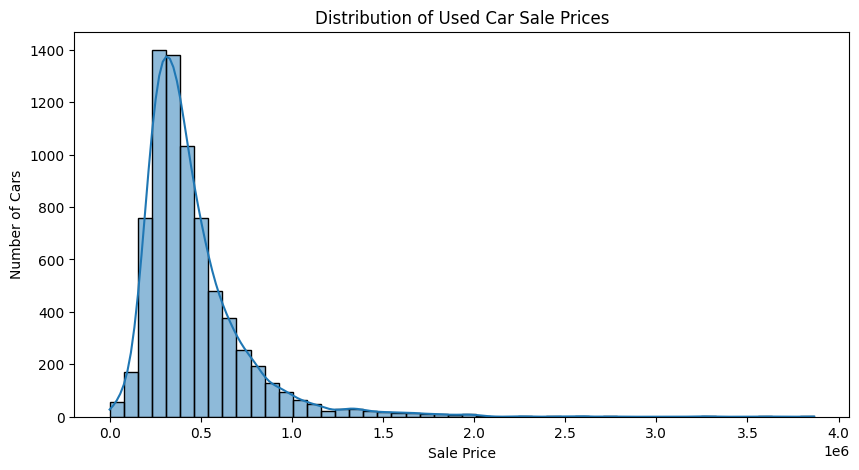

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df["sale_price"], bins=50, kde=True)

plt.title("Distribution of Used Car Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Cars")
plt.show()

In [14]:
print("Top 15 Car Brands:")
print(df["make"].value_counts().head(15))

Top 15 Car Brands:
make
maruti           3179
hyundai          1800
honda             592
toyota            365
renault           258
volkswagen        253
mahindra          227
ford              203
tata              158
skoda              68
chevrolet          52
nissan             50
mercedes benz      39
datsun             34
bmw                33
Name: count, dtype: int64


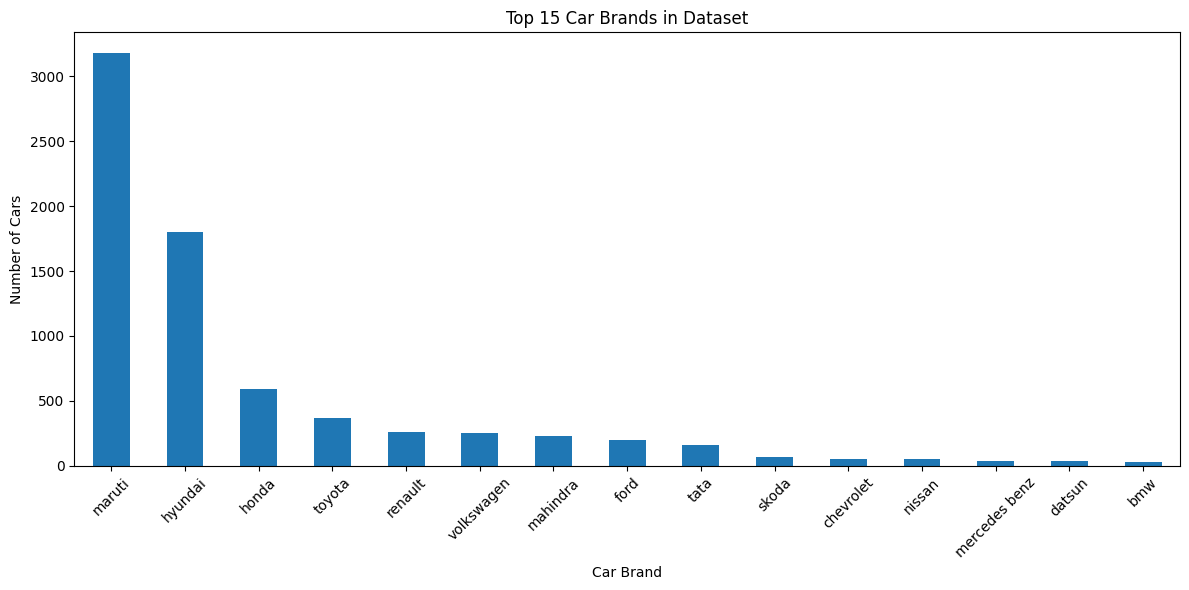

In [15]:
plt.figure(figsize=(12, 6))

df["make"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Car Brands in Dataset")
plt.xlabel("Car Brand")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
current_year = 2026

df["car_age"] = current_year - df["yr_mfr"]

print(df[["yr_mfr", "car_age", "sale_price"]].head())

   yr_mfr  car_age  sale_price
0    2015       11      386399
1    2016       10      265499
2    2017        9      477699
3    2013       13      307999
4    2015       11      361499


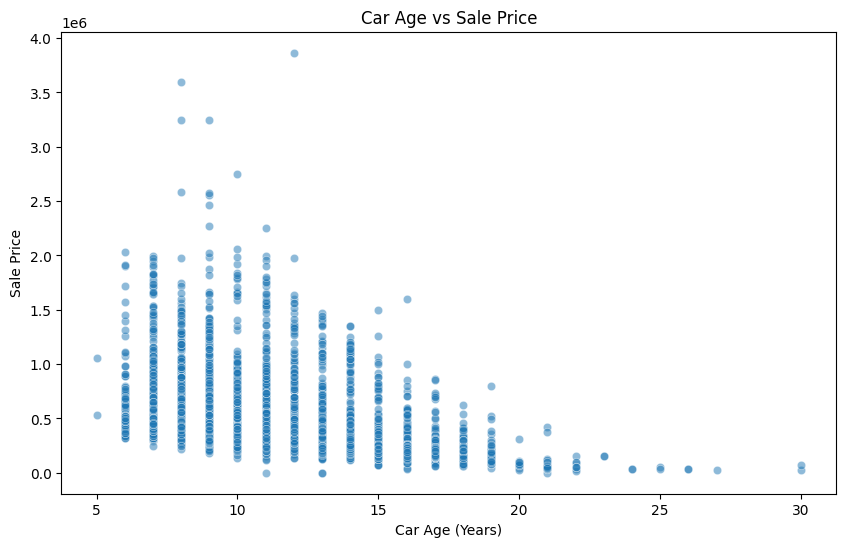

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="car_age",
    y="sale_price",
    alpha=0.5
)

plt.title("Car Age vs Sale Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Sale Price")
plt.show()

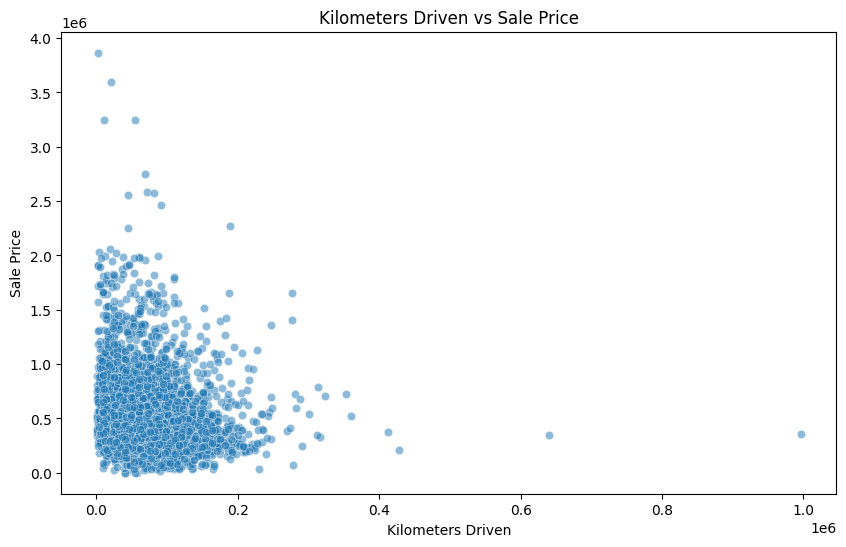

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="kms_run",
    y="sale_price",
    alpha=0.5
)

plt.title("Kilometers Driven vs Sale Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Sale Price")
plt.show()

In [19]:
# Detect outliers using IQR method

Q1 = df["sale_price"].quantile(0.25)
Q3 = df["sale_price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = df[
    (df["sale_price"] < lower_limit) |
    (df["sale_price"] > upper_limit)
]

print("\nNumber of outliers:", len(outliers))
print("Percentage of outliers:", round(len(outliers) / len(df) * 100, 2), "%")

Q1: 281174.0
Q3: 540149.0
IQR: 258975.0
Lower Limit: -107288.5
Upper Limit: 928611.5

Number of outliers: 412
Percentage of outliers: 5.57 %


In [20]:
outliers[
    ["make", "model", "yr_mfr", "kms_run", "sale_price"]
].sort_values("sale_price", ascending=False).head(20)

,make,model,yr_mfr,kms_run,sale_price
6900,jaguar,xj l,2014,2288,3866000
5970,audi,a4,2018,20379,3600000
7310,mercedes benz,c class,2017,10579,3250000
3756,toyota,fortuner,2018,54802,3250000
7242,audi,q3,2016,68290,2750000
2498,toyota,fortuner,2018,71824,2585899
7309,toyota,fortuner,2017,81861,2571559
3350,toyota,fortuner,2017,45112,2558429
3748,toyota,fortuner,2017,91620,2462277
4937,toyota,fortuner,2017,188558,2269771


In [21]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Total Outliers:", len(outliers))

Q1: 281174.0
Q3: 540149.0
IQR: 258975.0
Lower Limit: -107288.5
Upper Limit: 928611.5
Total Outliers: 412


In [22]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 1


In [23]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Duplicate rows found:", len(duplicate_rows))

duplicate_rows.head(10)

Duplicate rows found: 2


,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail,car_age
2323,mahindra thar,2017,diesel,37134,671399,new delhi,4603,suv,manual,crde 4x4 bs iv,...,646565,NaN,great,2021-03-07T10:10:19.937,True,15595,100710,True,False,9
7399,mahindra thar,2017,diesel,37134,671399,new delhi,4603,suv,manual,crde 4x4 bs iv,...,646565,NaN,great,2021-03-07T10:10:19.937,True,15595,100710,True,False,9


In [24]:
print("Year range:")
print(df["yr_mfr"].min(), "to", df["yr_mfr"].max())

print("\nKilometers range:")
print(df["kms_run"].min(), "to", df["kms_run"].max())

print("\nSale price range:")
print(df["sale_price"].min(), "to", df["sale_price"].max())

Year range:
1996 to 2021

Kilometers range:
60 to 996609

Sale price range:
0 to 3866000


In [25]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Count", ascending=False)

missing_summary

,Missing Count,Missing %
original_price,3280,44.32
car_availability,620,8.38
transmission,556,7.51
source,126,1.70
body_type,103,1.39
registered_state,10,0.14
registered_city,10,0.14
car_rating,9,0.12
fitness_certificate,8,0.11
ad_created_on,1,0.01


In [27]:
# Make a fresh copy
df_clean = df.copy()

# Convert car_rating to numeric
df_clean["car_rating"] = pd.to_numeric(
    df_clean["car_rating"], errors="coerce"
)

# Categorical columns
categorical_cols = [
    "car_availability",
    "transmission",
    "source",
    "body_type",
    "registered_state",
    "registered_city",
    "fitness_certificate"
]

# Fill categorical missing values with mode
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Fill car_rating missing values with median
df_clean["car_rating"] = df_clean["car_rating"].fillna(
    df_clean["car_rating"].median()
)

# Fill date missing value with mode
df_clean["ad_created_on"] = df_clean["ad_created_on"].fillna(
    df_clean["ad_created_on"].mode()[0]
)

print("Missing values cleaned successfully!")
print("\nRemaining missing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values cleaned successfully!

Remaining missing values:
original_price    3280
car_rating        7400
dtype: int64


In [28]:
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nTotal missing values after cleaning:",
      df_clean.isnull().sum().sum())

Original dataset shape: (7400, 30)
Cleaned dataset shape: (7400, 30)

Total missing values after cleaning: 10680


In [29]:
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("Remaining missing values:")
print(remaining_missing)

Remaining missing values:
car_rating        7400
original_price    3280
dtype: int64


In [ ]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
df = pd.read_csv("../data/Used_Car_Price_Prediction.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 7400
Columns: 29


In [ ]:
df.head()

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False


In [ ]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['car_name', 'yr_mfr', 'fuel_type', 'kms_run', 'sale_price', 'city', 'times_viewed', 'body_type', 'transmission', 'variant', 'assured_buy', 'registered_city', 'registered_state', 'is_hot', 'rto', 'source', 'make', 'model', 'car_availability', 'total_owners', 'broker_quote', 'original_price', 'car_rating', 'ad_created_on', 'fitness_certificate', 'emi_starts_from', 'booking_down_pymnt', 'reserved', 'warranty_avail']


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             7400 non-null   str    
 1   yr_mfr               7400 non-null   int64  
 2   fuel_type            7400 non-null   str    
 3   kms_run              7400 non-null   int64  
 4   sale_price           7400 non-null   int64  
 5   city                 7400 non-null   str    
 6   times_viewed         7400 non-null   int64  
 7   body_type            7297 non-null   str    
 8   transmission         6844 non-null   str    
 9   variant              7400 non-null   str    
 10  assured_buy          7400 non-null   bool   
 11  registered_city      7390 non-null   str    
 12  registered_state     7390 non-null   str    
 13  is_hot               7400 non-null   bool   
 14  rto                  7400 non-null   str    
 15  source               7274 non-null   str    
 16 

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
car_name                  0
yr_mfr                    0
fuel_type                 0
kms_run                   0
sale_price                0
city                      0
times_viewed              0
body_type               103
transmission            556
variant                   0
assured_buy               0
registered_city          10
registered_state         10
is_hot                    0
rto                       0
source                  126
make                      0
model                     0
car_availability        620
total_owners              0
broker_quote              0
original_price         3280
car_rating                9
ad_created_on             1
fitness_certificate       8
emi_starts_from           0
booking_down_pymnt        0
reserved                  0
warranty_avail            0
dtype: int64


In [ ]:
# Complete missing-value summary
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

print("\nMissing percentage:")
print((missing / len(df) * 100).round(2))

Columns with missing values:
original_price         3280
car_availability        620
transmission            556
source                  126
body_type               103
registered_state         10
registered_city          10
car_rating                9
fitness_certificate       8
ad_created_on             1
dtype: int64

Missing percentage:
original_price         44.32
car_availability        8.38
transmission            7.51
source                  1.70
body_type               1.39
registered_state        0.14
registered_city         0.14
car_rating              0.12
fitness_certificate     0.11
ad_created_on           0.01
dtype: float64


In [ ]:
# Data types of all columns
print(df.dtypes)

car_name                   str
yr_mfr                   int64
fuel_type                  str
kms_run                  int64
sale_price               int64
city                       str
times_viewed             int64
body_type                  str
transmission               str
variant                    str
assured_buy               bool
registered_city            str
registered_state           str
is_hot                    bool
rto                        str
source                     str
make                       str
model                      str
car_availability           str
total_owners             int64
broker_quote             int64
original_price         float64
car_rating                 str
ad_created_on              str
fitness_certificate     object
emi_starts_from          int64
booking_down_pymnt       int64
reserved                  bool
warranty_avail            bool
dtype: object


In [ ]:
# Statistical summary
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_name,7400,185,maruti swift,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
yr_mfr,7400.0,NaN,NaN,NaN,2013.885676,3.087613,1996.0,2012.0,2014.0,2016.0,2021.0
fuel_type,7400,5,petrol,4659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kms_run,7400.0,NaN,NaN,NaN,62624.52,43532.042371,60.0,31885.25,55765.0,84184.0,996609.0
sale_price,7400.0,NaN,NaN,NaN,454889.192027,282702.329741,0.0,281174.0,382449.0,540149.0,3866000.0
city,7400,13,mumbai,1336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
times_viewed,7400.0,NaN,NaN,NaN,1550.706081,2080.952842,3.0,554.75,1088.0,1926.5,61930.0
body_type,7297,5,hatchback,4358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,6844,2,manual,6215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
variant,7400,943,vxi,674,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Create a fresh copy
df_clean = df.copy()

# -----------------------------
# 1. Categorical columns
# -----------------------------
categorical_cols = [
    "car_availability",
    "transmission",
    "source",
    "body_type",
    "registered_state",
    "registered_city",
    "car_rating",
    "fitness_certificate",
    "ad_created_on"
]

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


# -----------------------------
# 2. Original price
# -----------------------------
# Keep a missing-value indicator
df_clean["original_price_missing"] = df_clean["original_price"].isnull().astype(int)

# Fill missing original prices with median
df_clean["original_price"] = df_clean["original_price"].fillna(
    df_clean["original_price"].median()
)


# -----------------------------
# 3. Check remaining missing values
# -----------------------------
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[
    remaining_missing > 0
].sort_values(ascending=False)

print("Missing values cleaned successfully!")

print("\nRemaining missing values:")
print(remaining_missing)

print("\nTotal remaining missing values:",
      df_clean.isnull().sum().sum())

Missing values cleaned successfully!

Remaining missing values:
Series([], dtype: int64)

Total remaining missing values: 0


In [31]:
# Check duplicate rows

duplicates = df_clean.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 1


In [32]:
# Remove duplicate rows if any

if duplicates > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Dataset shape after duplicate removal:", df_clean.shape)

Dataset shape after duplicate removal: (7399, 31)


In [33]:
print("Invalid / suspicious values:")

print("\nManufacturing year:")
print("Minimum:", df_clean["yr_mfr"].min())
print("Maximum:", df_clean["yr_mfr"].max())

print("\nKilometers:")
print("Minimum:", df_clean["kms_run"].min())
print("Maximum:", df_clean["kms_run"].max())

print("\nSale price:")
print("Minimum:", df_clean["sale_price"].min())
print("Maximum:", df_clean["sale_price"].max())

Invalid / suspicious values:

Manufacturing year:
Minimum: 1996
Maximum: 2021

Kilometers:
Minimum: 60
Maximum: 996609

Sale price:
Minimum: 0
Maximum: 3866000


In [34]:
print("Negative/zero sale prices:",
      (df_clean["sale_price"] <= 0).sum())

print("Negative kilometers:",
      (df_clean["kms_run"] < 0).sum())

print("Invalid manufacturing years:",
      ((df_clean["yr_mfr"] < 1990) | (df_clean["yr_mfr"] > 2026)).sum())

Negative/zero sale prices: 3
Negative kilometers: 0
Invalid manufacturing years: 0


In [35]:
# Remove rows with zero or negative sale price

before = len(df_clean)

df_clean = df_clean[df_clean["sale_price"] > 0].copy()
df_clean.reset_index(drop=True, inplace=True)

after = len(df_clean)

print("Rows before cleaning:", before)
print("Invalid rows removed:", before - after)
print("Rows after cleaning:", after)

Rows before cleaning: 7399
Invalid rows removed: 3
Rows after cleaning: 7396


In [36]:
print("FINAL DATA QUALITY CHECK")
print("-------------------------")

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Invalid sale prices:", (df_clean["sale_price"] <= 0).sum())

FINAL DATA QUALITY CHECK
-------------------------
Rows: 7396
Columns: 31
Missing values: 0
Duplicate rows: 0
Invalid sale prices: 0


In [37]:
# Save cleaned dataset

cleaned_path = "../data/Used_Car_Price_Prediction_Cleaned.csv"

df_clean.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved successfully!")
print("File:", cleaned_path)
print("Rows:", len(df_clean))

Cleaned dataset saved successfully!
File: ../data/Used_Car_Price_Prediction_Cleaned.csv
Rows: 7396


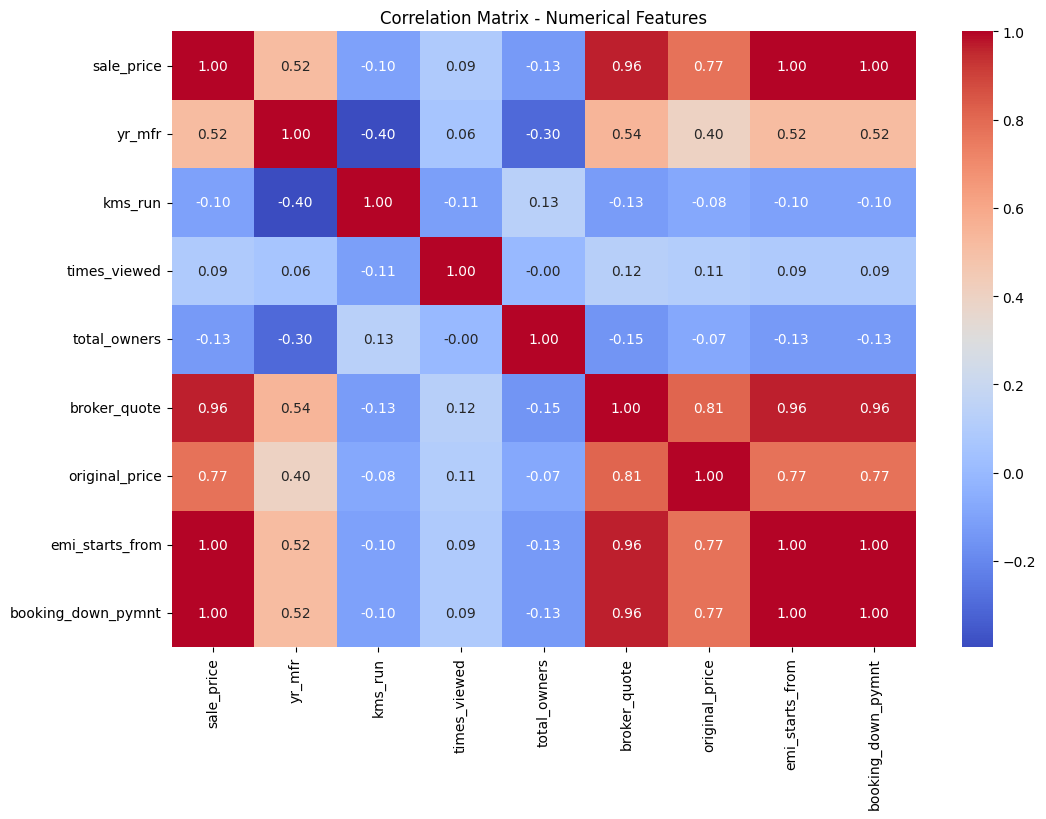

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Important numerical features
numeric_features = [
    "sale_price",
    "yr_mfr",
    "kms_run",
    "times_viewed",
    "total_owners",
    "broker_quote",
    "original_price",
    "emi_starts_from",
    "booking_down_pymnt"
]

# Correlation matrix
corr = df_clean[numeric_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Numerical Features")
plt.show()

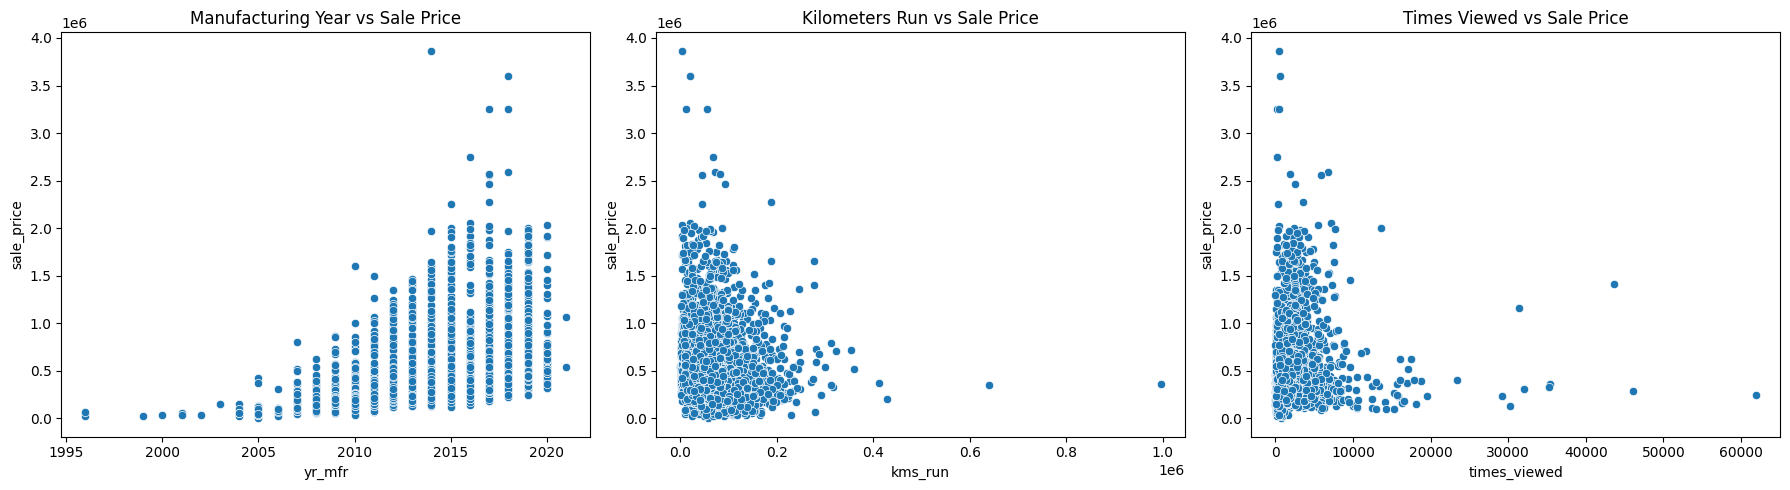

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df_clean, x="yr_mfr", y="sale_price", ax=axes[0])
axes[0].set_title("Manufacturing Year vs Sale Price")

sns.scatterplot(data=df_clean, x="kms_run", y="sale_price", ax=axes[1])
axes[1].set_title("Kilometers Run vs Sale Price")

sns.scatterplot(data=df_clean, x="times_viewed", y="sale_price", ax=axes[2])
axes[2].set_title("Times Viewed vs Sale Price")

plt.tight_layout()
plt.show()

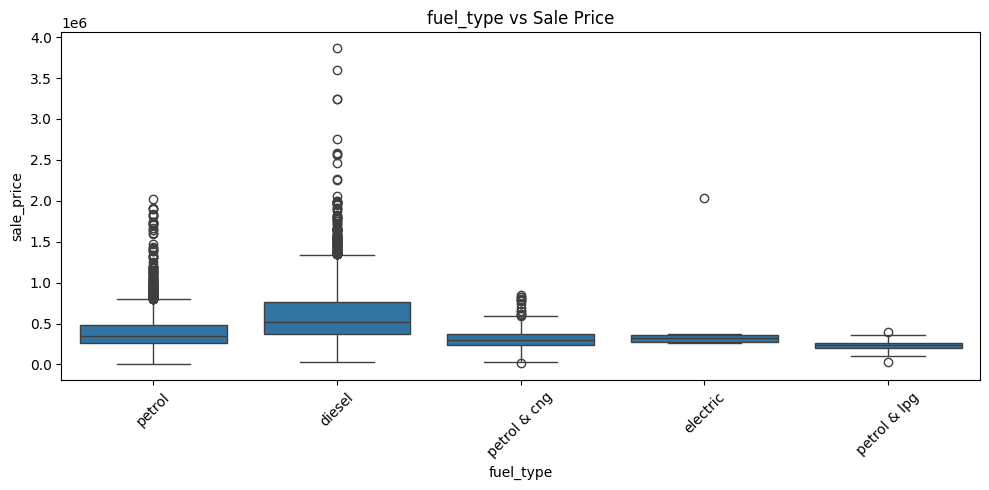

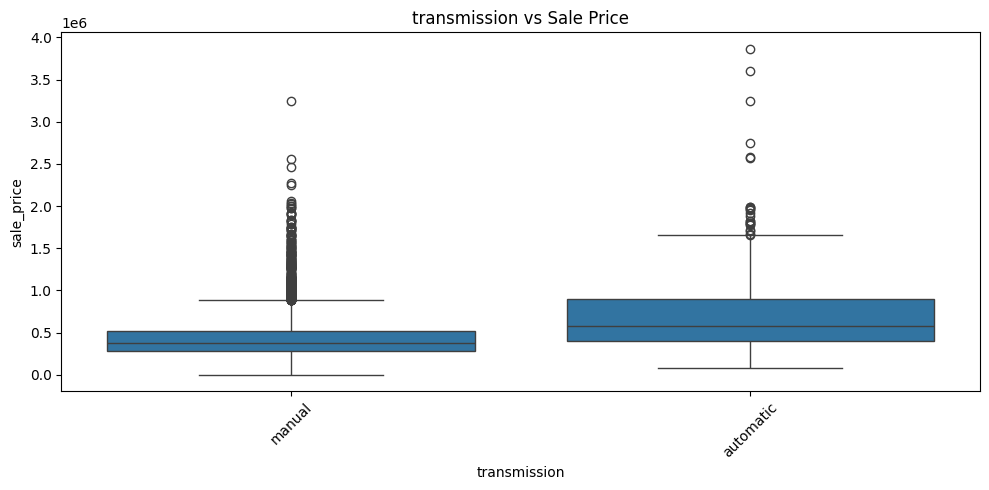

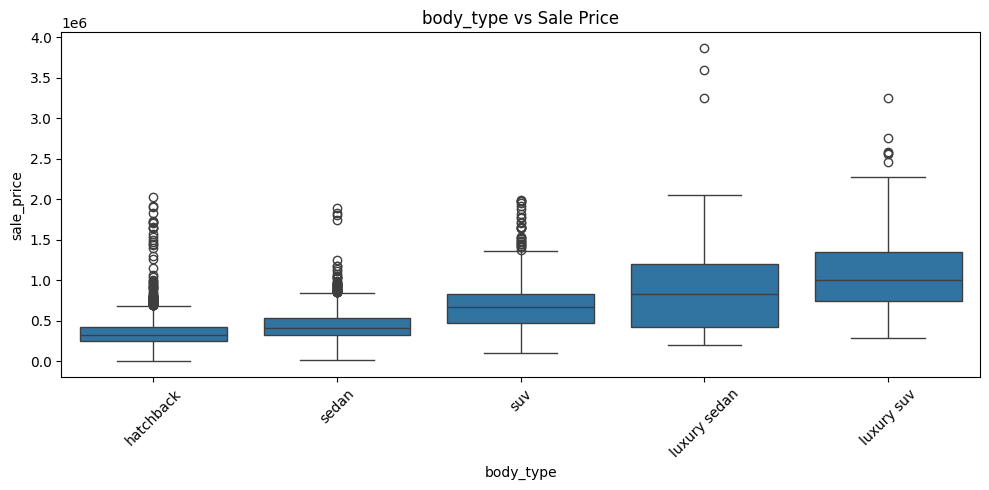

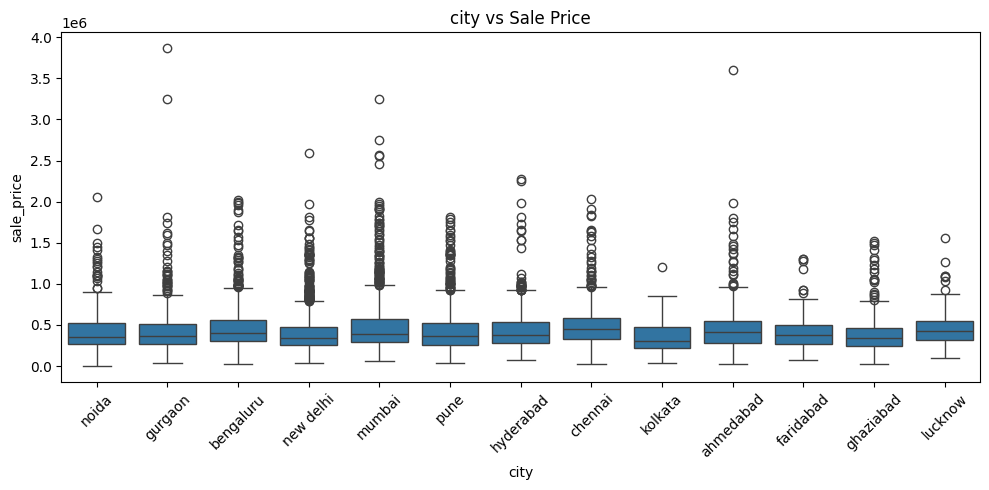

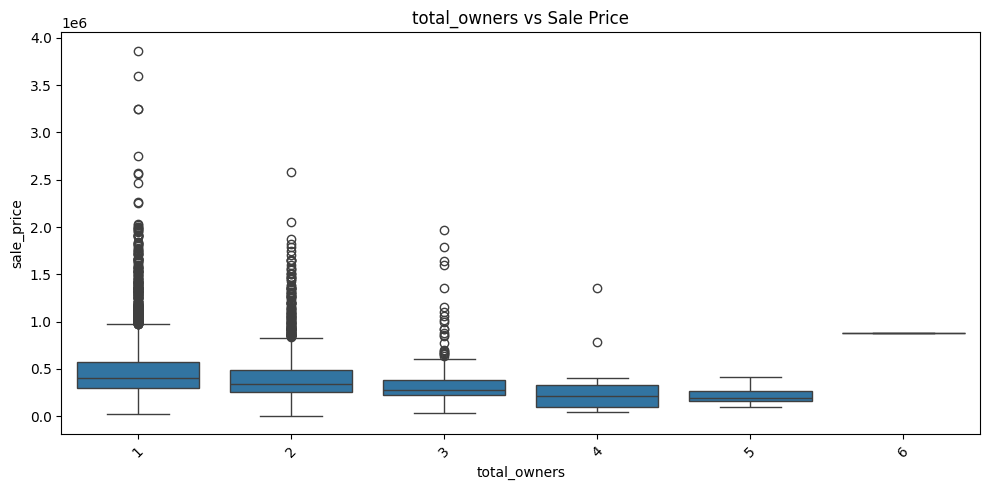

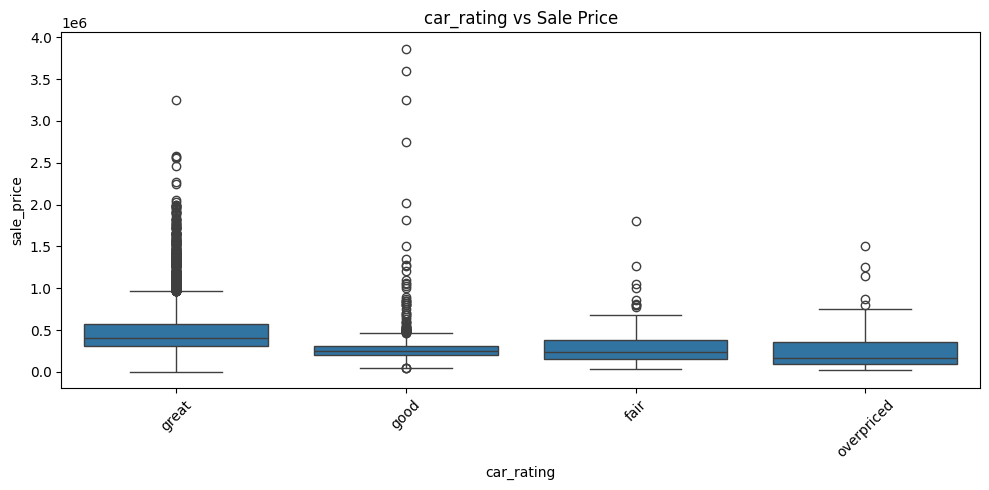

In [40]:
categorical_features = [
    "fuel_type",
    "transmission",
    "body_type",
    "city",
    "total_owners",
    "car_rating"
]

for col in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_clean, x=col, y="sale_price")
    plt.title(f"{col} vs Sale Price")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [41]:
# Convert date column to datetime
df_clean["ad_created_on"] = pd.to_datetime(
    df_clean["ad_created_on"],
    errors="coerce"
)

# Create useful date features
df_clean["ad_year"] = df_clean["ad_created_on"].dt.year
df_clean["ad_month"] = df_clean["ad_created_on"].dt.month
df_clean["ad_day"] = df_clean["ad_created_on"].dt.day

# Check result
print(df_clean[[
    "ad_created_on",
    "ad_year",
    "ad_month",
    "ad_day"
]].head())

            ad_created_on  ad_year  ad_month  ad_day
0 2021-04-04 07:09:18.583   2021.0       4.0     4.0
1 2021-03-22 14:07:32.833   2021.0       3.0    22.0
2 2021-03-20 05:36:31.311   2021.0       3.0    20.0
3 2021-01-21 12:59:19.299   2021.0       1.0    21.0
4 2021-04-01 13:33:40.733   2021.0       4.0     1.0


In [42]:
# Drop original date column
df_model = df_clean.drop(columns=["ad_created_on"]).copy()

print("Original shape:", df_clean.shape)
print("Model dataset shape:", df_model.shape)

print("\nCategorical columns:")
print(df_model.select_dtypes(include="object").columns.tolist())

Original shape: (7396, 34)
Model dataset shape: (7396, 33)

Categorical columns:
['car_name', 'fuel_type', 'city', 'body_type', 'transmission', 'variant', 'registered_city', 'registered_state', 'rto', 'source', 'make', 'model', 'car_availability', 'car_rating', 'fitness_certificate']


C:\Users\Sony\AppData\Local\Temp\ipykernel_10848\4053855676.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_model.select_dtypes(include="object").columns.tolist())


In [43]:
# Make a copy
df_encoded = df_model.copy()

# High-cardinality categorical columns
high_cardinality = [
    "car_name",
    "variant",
    "registered_city",
    "registered_state",
    "rto",
    "model"
]

# Frequency encoding
for col in high_cardinality:
    freq = df_encoded[col].value_counts(normalize=True)
    df_encoded[col + "_freq"] = df_encoded[col].map(freq)

# Drop original high-cardinality columns
df_encoded.drop(columns=high_cardinality, inplace=True)

# Low-cardinality categorical columns
low_cardinality = [
    "fuel_type",
    "city",
    "body_type",
    "transmission",
    "source",
    "make",
    "car_availability",
    "car_rating",
    "fitness_certificate"
]

# One-hot encoding
df_encoded = pd.get_dummies(
    df_encoded,
    columns=low_cardinality,
    drop_first=True,
    dtype=int
)

print("Encoding completed successfully!")
print("Original model features:", df_model.shape[1])
print("Encoded features:", df_encoded.shape[1])
print("Missing values:", df_encoded.isnull().sum().sum())

Encoding completed successfully!
Original model features: 33
Encoded features: 80
Missing values: 12


In [44]:
# Check remaining missing values
missing_encoded = df_encoded.isnull().sum()
missing_encoded = missing_encoded[missing_encoded > 0].sort_values(ascending=False)

print("Remaining missing values:")
print(missing_encoded)

print("\nTotal missing values:", missing_encoded.sum())

Remaining missing values:
ad_year     4
ad_month    4
ad_day      4
dtype: int64

Total missing values: 12


In [45]:
# Fill missing date-derived features with their median
date_features = ["ad_year", "ad_month", "ad_day"]

for col in date_features:
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())

# Verify
print("Missing values after date handling:")
print(df_encoded.isnull().sum().sum())

print("\nDate feature missing values:")
print(df_encoded[date_features].isnull().sum())

Missing values after date handling:
0

Date feature missing values:
ad_year     0
ad_month    0
ad_day      0
dtype: int64


In [46]:
# Separate features and target

X = df_encoded.drop(columns=["sale_price"])
y = df_encoded["sale_price"]

print("Features (X):", X.shape)
print("Target (y):", y.shape)

print("\nTarget column:")
print(y.name)

Features (X): (7396, 79)
Target (y): (7396,)

Target column:
sale_price


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5916, 79)
Testing data: (1480, 79)


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5916, 79)
Testing data: (1480, 79)


In [49]:
from sklearn.linear_model import LinearRegression

# Model create
lr_model = LinearRegression()

# Model train
lr_model.fit(X_train, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test)

print("Linear Regression trained successfully!")
print("First 5 predictions:")
print(y_pred_lr[:5])

Linear Regression trained successfully!
First 5 predictions:
[531998.85382123 232599.23099174 202799.52642154 794599.15425326
 346498.60026196]


In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE  :", round(mae_lr, 2))
print("RMSE :", round(rmse_lr, 2))
print("R²   :", round(r2_lr, 4))

Linear Regression Performance
-----------------------------
MAE  : 0.35
RMSE : 0.54
R²   : 1.0


In [51]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=15
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree trained successfully!")
print("First 5 predictions:")
print(y_pred_dt[:5])

Decision Tree trained successfully!
First 5 predictions:
[531799. 232399. 203099. 795000. 346399.]


In [52]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-------------------------")
print("MAE  :", round(mae_dt, 2))
print("RMSE :", round(rmse_dt, 2))
print("R²   :", round(r2_dt, 4))

Decision Tree Performance
-------------------------
MAE  : 917.39
RMSE : 13546.45
R²   : 0.9979


In [53]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully!")
print("First 5 predictions:")
print(y_pred_rf[:5])

Random Forest trained successfully!
First 5 predictions:
[531798.   232584.   202740.   794851.18 346530.  ]


In [54]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("------------------------")
print("MAE  :", round(mae_rf, 2))
print("RMSE :", round(rmse_rf, 2))
print("R²   :", round(r2_rf, 4))

Random Forest Performance
------------------------
MAE  : 626.71
RMSE : 7354.92
R²   : 0.9994


In [55]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost trained successfully!")
print("First 5 predictions:")
print(y_pred_xgb[:5])

XGBoost trained successfully!
First 5 predictions:
[531110.   232012.4  202887.64 793725.5  346270.94]


In [56]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-------------------")
print("MAE  :", round(mae_xgb, 2))
print("RMSE :", round(rmse_xgb, 2))
print("R²   :", round(r2_xgb, 4))

XGBoost Performance
-------------------
MAE  : 4340.98
RMSE : 43443.12
R²   : 0.9781


In [57]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_xgb
    ],
    "R2 Score": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_xgb
    ]
})

results = results.sort_values(by="RMSE")

print("Model Comparison")
print("================")
display(results.round(2))

Model Comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.35,0.54,1.00
2,Random Forest,626.71,7354.92,1.00
1,Decision Tree,917.39,13546.45,1.00
3,XGBoost,4340.98,43443.12,0.98


In [58]:
# Check which numerical features are most strongly related to sale_price

correlation = df_model.select_dtypes(include=np.number).corr()["sale_price"].sort_values(
    ascending=False
)

print("Features most correlated with sale_price:")
display(correlation.to_frame(name="Correlation").round(4))

Features most correlated with sale_price:


,Correlation
sale_price,1.0000
booking_down_pymnt,1.0000
emi_starts_from,1.0000
broker_quote,0.9637
original_price,0.7748
yr_mfr,0.5192
times_viewed,0.0912
ad_year,0.0751
ad_day,0.0104
ad_month,-0.0326


In [59]:
leakage_features = [
    "booking_down_pymnt",
    "emi_starts_from",
    "broker_quote"
]

df_model_clean = df_model.drop(columns=leakage_features)

print("Leakage features removed successfully!")
print("New shape:", df_model_clean.shape)
print("\nRemoved features:")
print(leakage_features)

Leakage features removed successfully!
New shape: (7396, 30)

Removed features:
['booking_down_pymnt', 'emi_starts_from', 'broker_quote']


In [60]:
Leakage features removed successfully!
New shape: (7396, 30)

Removed features:
['booking_down_pymnt', 'emi_starts_from', 'broker_quote']

SyntaxError: invalid syntax (1686381288.py, line 1)

In [61]:
# Copy cleaned model dataset
df_encoded_clean = df_model_clean.copy()

# High-cardinality categorical columns
high_cardinality = [
    "car_name",
    "variant",
    "registered_city",
    "registered_state",
    "rto",
    "model"
]

# Frequency Encoding
for col in high_cardinality:
    freq = df_encoded_clean[col].value_counts(normalize=True)
    df_encoded_clean[col + "_freq"] = df_encoded_clean[col].map(freq)

# Remove original high-cardinality columns
df_encoded_clean.drop(columns=high_cardinality, inplace=True)

# Low-cardinality categorical columns
low_cardinality = [
    "fuel_type",
    "city",
    "body_type",
    "transmission",
    "source",
    "make",
    "car_availability",
    "car_rating",
    "fitness_certificate"
]

# One-Hot Encoding
df_encoded_clean = pd.get_dummies(
    df_encoded_clean,
    columns=low_cardinality,
    drop_first=True,
    dtype=int
)

# Handle any remaining missing values
df_encoded_clean = df_encoded_clean.fillna(0)

print("Clean encoding completed successfully!")
print("Final shape:", df_encoded_clean.shape)
print("Missing values:", df_encoded_clean.isnull().sum().sum())

Clean encoding completed successfully!
Final shape: (7396, 77)
Missing values: 0


In [62]:
X_clean = df_encoded_clean.drop(columns=["sale_price"])
y_clean = df_encoded_clean["sale_price"]

print("Features (X):", X_clean.shape)
print("Target (y):", y_clean.shape)
print("Target column:", y_clean.name)

Features (X): (7396, 76)
Target (y): (7396,)
Target column: sale_price


In [63]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train_clean.shape)
print("Testing data:", X_test_clean.shape)

Training data: (5916, 76)
Testing data: (1480, 76)


In [64]:
from sklearn.linear_model import LinearRegression

lr_clean_model = LinearRegression()

lr_clean_model.fit(X_train_clean, y_train_clean)

y_pred_lr_clean = lr_clean_model.predict(X_test_clean)

print("Clean Linear Regression trained successfully!")
print("First 5 predictions:")
print(y_pred_lr_clean[:5])

Clean Linear Regression trained successfully!
First 5 predictions:
[520611.97262373 225053.40590642 113931.38042341 736105.47939072
 238381.07075274]


In [65]:
mae_lr_clean = mean_absolute_error(y_test_clean, y_pred_lr_clean)
rmse_lr_clean = np.sqrt(mean_squared_error(y_test_clean, y_pred_lr_clean))
r2_lr_clean = r2_score(y_test_clean, y_pred_lr_clean)

print("Clean Linear Regression Performance")
print("-----------------------------------")
print("MAE  :", round(mae_lr_clean, 2))
print("RMSE :", round(rmse_lr_clean, 2))
print("R²   :", round(r2_lr_clean, 4))

Clean Linear Regression Performance
-----------------------------------
MAE  : 87016.19
RMSE : 141780.07
R²   : 0.7669


In [66]:
from sklearn.tree import DecisionTreeRegressor

dt_clean_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=15
)

dt_clean_model.fit(X_train_clean, y_train_clean)

y_pred_dt_clean = dt_clean_model.predict(X_test_clean)

print("Clean Decision Tree trained successfully!")
print("First 5 predictions:")
print(y_pred_dt_clean[:5])

Clean Decision Tree trained successfully!
First 5 predictions:
[509138.47368421 244629.76923077 252174.         777599.
 293799.        ]


In [67]:
mae_dt_clean = mean_absolute_error(y_test_clean, y_pred_dt_clean)
rmse_dt_clean = np.sqrt(mean_squared_error(y_test_clean, y_pred_dt_clean))
r2_dt_clean = r2_score(y_test_clean, y_pred_dt_clean)

print("Clean Decision Tree Performance")
print("--------------------------------")
print("MAE  :", round(mae_dt_clean, 2))
print("RMSE :", round(rmse_dt_clean, 2))
print("R²   :", round(r2_dt_clean, 4))

Clean Decision Tree Performance
--------------------------------
MAE  : 54524.46
RMSE : 111457.14
R²   : 0.8559


In [68]:
from sklearn.ensemble import RandomForestRegressor

rf_clean_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_clean_model.fit(X_train_clean, y_train_clean)

y_pred_rf_clean = rf_clean_model.predict(X_test_clean)

print("Clean Random Forest trained successfully!")
print("First 5 predictions:")
print(y_pred_rf_clean[:5])

Clean Random Forest trained successfully!
First 5 predictions:
[504816.50439533 216552.31393867 237426.77942038 777738.26527778
 305048.90251364]


In [69]:
mae_rf_clean = mean_absolute_error(y_test_clean, y_pred_rf_clean)
rmse_rf_clean = np.sqrt(mean_squared_error(y_test_clean, y_pred_rf_clean))
r2_rf_clean = r2_score(y_test_clean, y_pred_rf_clean)

print("Clean Random Forest Performance")
print("--------------------------------")
print("MAE  :", round(mae_rf_clean, 2))
print("RMSE :", round(rmse_rf_clean, 2))
print("R²   :", round(r2_rf_clean, 4))

Clean Random Forest Performance
--------------------------------
MAE  : 43887.67
RMSE : 83871.97
R²   : 0.9184


In [70]:
from xgboost import XGBRegressor

xgb_clean_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_clean_model.fit(X_train_clean, y_train_clean)

y_pred_xgb_clean = xgb_clean_model.predict(X_test_clean)

print("Clean XGBoost trained successfully!")
print("First 5 predictions:")
print(y_pred_xgb_clean[:5])

Clean XGBoost trained successfully!
First 5 predictions:
[517883.3  220597.3  196264.64 807774.6  323091.44]


In [71]:
mae_xgb_clean = mean_absolute_error(y_test_clean, y_pred_xgb_clean)
rmse_xgb_clean = np.sqrt(mean_squared_error(y_test_clean, y_pred_xgb_clean))
r2_xgb_clean = r2_score(y_test_clean, y_pred_xgb_clean)

print("Clean XGBoost Performance")
print("-------------------------")
print("MAE  :", round(mae_xgb_clean, 2))
print("RMSE :", round(rmse_xgb_clean, 2))
print("R²   :", round(r2_xgb_clean, 4))

Clean XGBoost Performance
-------------------------
MAE  : 40996.51
RMSE : 78489.41
R²   : 0.9286


In [72]:
import joblib

model_path = "../models/used_car_price_xgboost.pkl"

joblib.dump(xgb_clean_model, model_path)

print("Best model saved successfully!")
print("Model:", model_path)

Best model saved successfully!
Model: ../models/used_car_price_xgboost.pkl


In [73]:
feature_columns = X_clean.columns.tolist()

joblib.dump(feature_columns, "../models/feature_columns.pkl")

print("Feature list saved successfully!")
print("Total features:", len(feature_columns))
print("\nFirst 10 features:")
print(feature_columns[:10])

Feature list saved successfully!
Total features: 76

First 10 features:
['yr_mfr', 'kms_run', 'times_viewed', 'assured_buy', 'is_hot', 'total_owners', 'original_price', 'reserved', 'warranty_avail', 'car_age']


In [74]:
import joblib

# Load saved model
loaded_model = joblib.load("../models/used_car_price_xgboost.pkl")

# Take one test car
sample_car = X_test_clean.iloc[[0]]
actual_price = y_test_clean.iloc[0]

# Predict
predicted_price = loaded_model.predict(sample_car)[0]

print("Saved model loaded successfully!")
print("--------------------------------")
print("Actual Sale Price   : ₹", round(actual_price, 2))
print("Predicted Sale Price: ₹", round(predicted_price, 2))
print("Difference          : ₹", round(abs(actual_price - predicted_price), 2))

Saved model loaded successfully!
--------------------------------
Actual Sale Price   : ₹ 531999
Predicted Sale Price: ₹ 517883.3
Difference          : ₹ 14115.69
